In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Dataset_creditcard.csv')

In [3]:
#Read the data

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [5]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [6]:
df.info

<bound method DataFrame.info of             Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \
0       0.462388  0.239599  

In [7]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1081)

In [9]:
#check the duplicate

df[df.duplicated()]['Class'].value_counts()

Class
0    1062
1      19
Name: count, dtype: int64

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [14]:
#target variable
df['Class'].value_counts(normalize=True)*100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

In [15]:
#The dataset is highly imbalanced, with approximately 99.83% genuine transactions and only 0.17% fraudulent transactions.

In [16]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [17]:
#charts

In [ ]:
#The Amount data is highly right-skewed, with most transactions having lower values.

In [20]:
#box plot to indetify the outlier

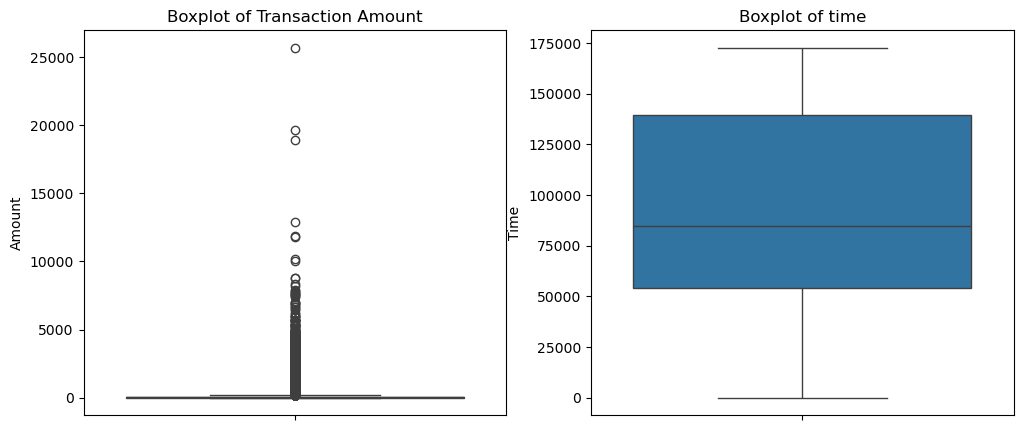

In [21]:
plt.figure(figsize=(12,5))

#Amount
plt.subplot(1,2,1)
sns.boxplot(y=df['Amount'])
plt.title('Boxplot of Transaction Amount')

#time boxplot
plt.subplot(1,2,2)
sns.boxplot(y=df['Time'])
plt.title('Boxplot of time')


plt.show()



In [22]:
#Amount shows many potential outliers, while time doesn't show obvious outliers.

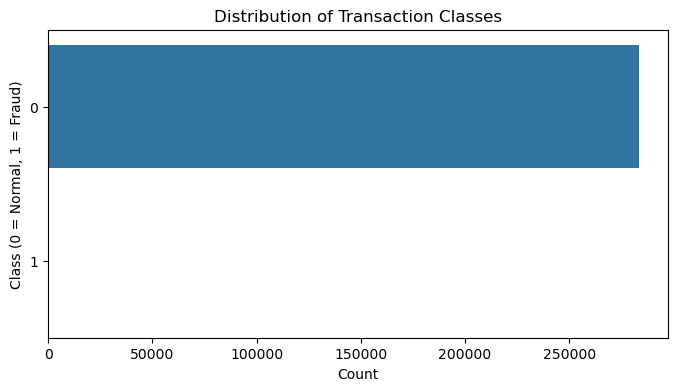

In [25]:
plt.figure(figsize=(8,4))

sns.countplot(y='Class', data=df)

plt.title('Distribution of Transaction Classes')
plt.xlabel('Count')
plt.ylabel('Class (0 = Normal, 1 = Fraud)')

plt.show()

In [27]:
df.corr()['Class'].sort_values()

V17      -0.313498
V14      -0.293375
V12      -0.250711
V10      -0.206971
V16      -0.187186
V3       -0.182322
V7       -0.172347
V18      -0.105340
V1       -0.094486
V9       -0.094021
V5       -0.087812
V6       -0.043915
Time     -0.012359
V24      -0.007210
V23      -0.006333
V13      -0.003897
V15      -0.003300
V25       0.003202
V26       0.004265
V22       0.004887
Amount    0.005777
V28       0.009682
V20       0.021486
V27       0.021892
V21       0.026357
V8        0.033068
V19       0.033631
V2        0.084624
V4        0.129326
V11       0.149067
Class     1.000000
Name: Class, dtype: float64

In [28]:
#V17, V14, V12 and V10 show the strongest negative correlations with fraud, 
#while V11 and V4 show notable positive correlations. 
#Amount and Time show very weak linear correlations with the target variable.

In [29]:
df['Hour'] = (df['Time'] % 86400) // 3600
df['Day'] = df['Time'] // 86400

In [30]:
df[['Time', 'Hour', 'Day']].head()

,Time,Hour,Day
0,0.0,0.0,0.0
1,0.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,2.0,0.0,0.0


In [31]:
#Separate features and target

x = df.drop('Class', axis=1)
y = df['Class']

print(x.shape)
print(y.shape)

(283726, 32)
(283726,)


In [32]:
from sklearn.model_selection import train_test_split

In [33]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [34]:
print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

x_train: (226980, 32)
x_test: (56746, 32)
y_train: (226980,)
y_test: (56746,)


In [35]:
from sklearn.preprocessing import StandardScaler

In [36]:
#Scaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(x_train_scaled.shape)
print(x_test_scaled.shape)

(226980, 32)
(56746, 32)


In [37]:
#using SMOTE for balacing the data

from imblearn.over_sampling import SMOTE

In [38]:
smote = SMOTE(random_state=42)

x_train_balanced,y_train_balanced = smote.fit_resample(x_train,y_train)
print("SMOTE applied successfully!")

SMOTE applied successfully!


In [39]:
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_balanced.value_counts())

Before SMOTE: Class
0    226602
1       378
Name: count, dtype: int64
After SMOTE: Class
0    226602
1    226602
Name: count, dtype: int64


In [40]:
print("x_train before SMOTE:", x_train_scaled.shape)
print("x_train after SMOTE:", x_train_balanced.shape)

x_train before SMOTE: (226980, 32)
x_train after SMOTE: (453204, 32)


In [41]:

### Logistic Regression

In [42]:
from sklearn.linear_model import LogisticRegression

In [43]:
from sklearn.metrics import confusion_matrix, classification_report

In [44]:
def eval_model(ytest, ypred):
    cm = confusion_matrix(ytest, ypred)
    crep = classification_report(ytest, ypred)
    print(cm)
    print(crep)

In [45]:
lr1 = LogisticRegression(max_iter=1000)
lr1.fit(x_train_balanced,y_train_balanced)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [46]:
ypred_lr1 = lr1.predict(x_test_scaled)
eval_model(y_test, ypred_lr1)

[[47352  9299]
 [   13    82]]
              precision    recall  f1-score   support

           0       1.00      0.84      0.91     56651
           1       0.01      0.86      0.02        95

    accuracy                           0.84     56746
   macro avg       0.50      0.85      0.46     56746
weighted avg       1.00      0.84      0.91     56746



In [47]:
print("Model Score:", lr1.score(x_test_scaled, y_test))

Model Score: 0.8359003277764071


In [61]:
#hyper tuning
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('logreg', LogisticRegression(max_iter=1000))
])

In [49]:
param_dist = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],
    'logreg__penalty': ['l1', 'l2'],
    'logreg__solver': ['liblinear', 'saga']
}
print('successful!')

successful!


In [50]:
rrs_lr = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=4,
    cv=3,
    scoring='f1',
    random_state=57,
    n_jobs=-1
)

In [51]:
rrs_lr.fit(x_train, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"{'logreg__C': [0.01, 0.1, ...], 'logreg__penalty': ['l1', 'l2'], 'logreg__solver': ['liblinear', 'saga']}"
,n_iter,4
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,57
,error_score,nan


In [53]:
print("Best Parameters:", rrs_lr.best_params_)
print("Best CV F1 Score:", rrs_lr.best_score_)

Best Parameters: {'logreg__solver': 'liblinear', 'logreg__penalty': 'l1', 'logreg__C': 0.01}
Best CV F1 Score: 0.10800377949456581


In [62]:
lr2 = rrs_lr.best_estimator_
ypred_lr2 = lr2.predict(x_test)
eval_model(y_test, ypred_lr2)
print("F1 Score:", f1_score(y_test, ypred_lr2))

[[55179  1472]
 [   12    83]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746

F1 Score: 0.1006060606060606


In [ ]:
#After tuning, false positives reduced from 9,299 to 1,472 while maintaining 87% recall; next,
#I will try reducing the SMOTE ratio to check if false positives can be reduced further.

In [66]:
ypred_proba_lr2 = lr2.predict_proba(x_test)[:, 1]

In [67]:
ypred_proba_lr2[:10]

array([0.03155087, 0.02935763, 0.01213654, 0.0170784 , 0.13182575,
       0.09035089, 0.01252394, 0.03661642, 0.08222962, 0.00072998])

In [68]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [69]:
print("Accuracy:", accuracy_score(y_test, ypred_lr2))
print("Precision:", precision_score(y_test, ypred_lr2))
print("Recall:", recall_score(y_test, ypred_lr2))
print("F1 Score:", f1_score(y_test, ypred_lr2))
print("ROC-AUC:", roc_auc_score(y_test, ypred_proba_lr2))

Accuracy: 0.973848376978113
Precision: 0.05337620578778135
Recall: 0.8736842105263158
F1 Score: 0.1006060606060606
ROC-AUC: 0.9673186425844669


In [70]:
#plot comfusion martix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

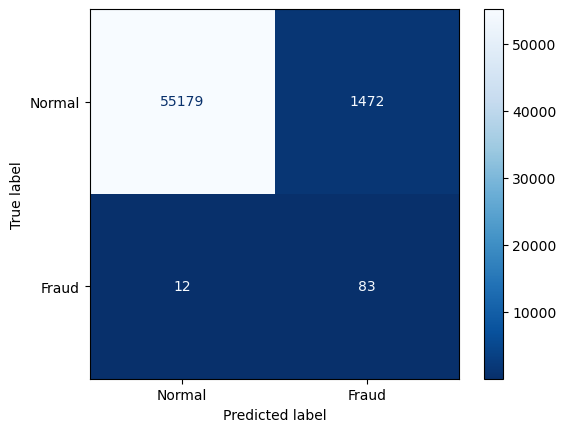

In [80]:
cm = confusion_matrix(y_test, ypred_lr2)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Normal', 'Fraud']
)

disp.plot(cmap='Blues_r')
plt.show()

In [3]:
#Observation: The tuned Logistic Regression model achieved 87.37% fraud recall and 96.73% ROC-AUC, detecting 83 out of 95 fraud cases. 
#However, the low precision of 5.34% and 1,472 false positives indicate that further improvement is required to reduce false fraud alerts.

In [81]:
#Note: To reduce false positive fraud alerts, 
#I will test a lower SMOTE sampling ratio of 0.1 and compare its precision, recall, F1-score, and confusion matrix with the current tuned model.

In [82]:
smote_10 = SMOTE(sampling_strategy=0.1, random_state=57)

x_train_smote10, y_train_smote10 = smote_10.fit_resample(x_train_scaled, y_train)

print(y_train_smote10.value_counts())

print('compelted')

Class
0    226602
1     22660
Name: count, dtype: int64
compelted


In [83]:
lr_smote10 = LogisticRegression(max_iter=1000)

lr_smote10.fit(x_train_smote10, y_train_smote10)

print('done')

done


In [86]:
ypred_smote10 = lr_smote10.predict(x_test_scaled)
eval_model(y_test,ypred_smote10)

[[56536   115]
 [   19    76]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.40      0.80      0.53        95

    accuracy                           1.00     56746
   macro avg       0.70      0.90      0.77     56746
weighted avg       1.00      1.00      1.00     56746



In [88]:
ypred_proba_smote10 = lr_smote10.predict_proba(x_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, ypred_smote10))
print("Precision:", precision_score(y_test, ypred_smote10))
print("Recall:", recall_score(y_test, ypred_smote10))
print("F1 Score:", f1_score(y_test, ypred_smote10))
print("ROC-AUC:", roc_auc_score(y_test, ypred_proba_smote10))

Accuracy: 0.9976386000775385
Precision: 0.39790575916230364
Recall: 0.8
F1 Score: 0.5314685314685315
ROC-AUC: 0.9697741202134212


In [ ]:
#hyper tuning the model somte_10

In [90]:
param_dist_smote_10 = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

In [91]:
rs_lr_01 = RandomizedSearchCV(
    estimator=lr_smote10,
    param_distributions=param_dist_smote_10,
    n_iter=4,
    cv=3,
    scoring='f1',
    random_state=57,
    n_jobs=-1
)
rs_lr_01.fit(x_train_smote10, y_train_smote10)

,estimator,LogisticRegre...max_iter=1000)
,param_distributions,"{'C': [0.01, 0.1, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'saga']}"
,n_iter,4
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,57
,error_score,nan


In [93]:
ypred_smote10 = rs_lr_01.predict(x_test_scaled)
eval_model(y_test,ypred_smote10)

[[56561    90]
 [   19    76]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.46      0.80      0.58        95

    accuracy                           1.00     56746
   macro avg       0.73      0.90      0.79     56746
weighted avg       1.00      1.00      1.00     56746



In [94]:
ypred_proba_smote10_tuned = rs_lr_01.predict_proba(x_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, ypred_smote10))
print("Precision:", precision_score(y_test, ypred_smote10))
print("Recall:", recall_score(y_test, ypred_smote10))
print("F1 Score:", f1_score(y_test, ypred_smote10))
print("ROC-AUC:", roc_auc_score(y_test, ypred_proba_smote10_tuned))

Accuracy: 0.9980791597645648
Precision: 0.4578313253012048
Recall: 0.8
F1 Score: 0.5823754789272031
ROC-AUC: 0.966879573826448


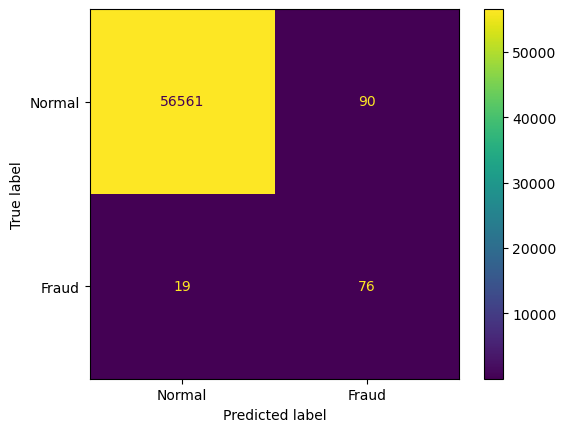

In [95]:
cm_smote10 = confusion_matrix(y_test, ypred_smote10)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_smote10,
    display_labels=['Normal', 'Fraud']
)

disp.plot()
plt.show()

In [ ]:
#Observation: Reducing SMOTE to 0.1 and tuning the model significantly reduced false positives from 1,472 to 90 while maintaining 80% fraud recall. 
#Precision and F1-score also improved, giving a better overall balance between fraud detection and false alarms.